## House Prices - Exploratory Data Analysis
This notebook performs end-to-end EDA on the Ames Housing dataset from Kaggle.  
The goal is to predict `SalePrice` by uncovering patterns, distributions, and relationships hidden in the data — insights that directly guide feature engineering and modeling decisions.
 
**Author:** Muhammad Umer Asad | [Kaggle](https://www.kaggle.com/datawithumerz)| [GitHub](https://github.com/datawithumerz)

### Dataset Overview

The Ames Housing dataset contains detailed information about residential properties sold in Ames, Iowa. It has 1460 rows and 83 columns covering physical attributes, quality ratings, neighborhood, and sale conditions. The target variable is `SalePrice` — the final sale price of each house.

**Source:** [Kaggle — House Prices: Advanced Regression Techniques](https://www.kaggle.com/datasets/rishitaverma02/house-prices-advanced-regression-techniques)

### Table of Contents
1. [Setup & Data Loading](#1.-Setup-&-Data-Loading)
   - 1a. Import Libraries
   - 1b. Load Data
   - 1c. Initial Data Inspection
2. [Data Problems](#2.-Data-Problems)
   - 2a. High Missing Value Columns (Top 6)
   - 2b. Other Missing Value Columns
   - 2c. Missing Value Treatment
   - 2d. Verification — Null Check
   - 2e. Duplicates Check
   - 2f. Data Type Corrections
3. [Exploratory Data Analysis](#3.-Exploratory-Data-Analysis)
   - 3a. Univariate Analysis — Numerical
   - 3b. Univariate Analysis — Categorical
   - 3c. Bivariate Analysis — Numeric vs Numeric
   - 3d. Bivariate Analysis — Numeric vs Categorical
   - 3e. Categorical Column Selection by Price Spread
   - 3f. Bivariate Analysis — Categorical vs Categorical
   - 3g. Multivariate Analysis
4. [EDA Conclusion](#4.-EDA-Conclusion)
5. [Next Steps](#5.-Next-Steps)

### 1. Setup & Data Loading

1a. **Import Libraries**: Importing core libraries like NumPy, Pandas, Seaborn, Matplotlib

In [106]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
import warnings
warnings.filterwarnings('ignore')

1b. **Load Data**: Loading the dataset into `df`  

In [107]:
df=pd.read_csv("./data/raw/ames-housing.csv")

1c. **Initial Data Inspection**:first few rows and column info (dtypes, non-null counts)

In [108]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### 2. **Data Problems**

#### 2a. High Missing Value Columns (Top 6)

**Issue 1: PoolQC Missing Values**  
`PoolQC` had many null values. Cross-checking with `PoolArea` revealed that wherever `PoolQC` was null, `PoolArea = 0` — meaning no pool exists. These were not true missing values; `NA` simply means "No Pool." No rows dropped.

In [110]:
df['PoolArea'][df['PoolQC'].isnull()].sample(10)

217     0
915     0
638     0
27      0
1109    0
397     0
697     0
104     0
1266    0
327     0
Name: PoolArea, dtype: int64

In [111]:
df['PoolQC'][df['PoolQC'].notnull()]

197     Ex
810     Fa
1170    Gd
1182    Ex
1298    Gd
1386    Fa
1423    Gd
Name: PoolQC, dtype: object

**Issue 2: MiscFeature   Missing Values**  
`MiscFeature` had many null values. Cross-checking with `MiscVal` revealed that wherever `MiscFeature` was null, `MiscVal = 0` — meaning no miscellaneous feature exists. These were not true missing values; `NA` simply means "No Miscellaneous Feature." No rows dropped.

In [112]:
df['MiscVal'][df['MiscFeature'].isnull()].sample(10)

748     0
473     0
494     0
1391    0
1416    0
1041    0
670     0
1358    0
537     0
1448    0
Name: MiscVal, dtype: int64

In [113]:
df['MiscFeature'][df['MiscFeature'].notnull()].value_counts()

MiscFeature
Shed    49
Gar2     2
Othr     2
TenC     1
Name: count, dtype: int64

In [114]:
df['MiscVal'][df['MiscFeature'].notnull()].value_counts()

MiscVal
400      11
500       8
700       5
450       4
2000      4
600       4
1200      2
480       2
0         2
15500     1
800       1
350       1
3500      1
1300      1
54        1
620       1
560       1
1400      1
8300      1
1150      1
2500      1
Name: count, dtype: int64

**Issue 3: Alley Missing Values**  
`Alley` had 1369 null values. Only 91 houses have an alley (Gravel or Paved). It is likely that missing values mean "No Alley" (`NA`), but unlike `PoolQC`, no secondary column exists to cross-verify this assumption.

In [115]:
df['Alley'][df['Alley'].notnull()].value_counts()

Alley
Grvl    50
Pave    41
Name: count, dtype: int64

**Issue 4: Fence Missing Values**  
`Fence` had 1179 null values. Only 281 houses have a fence. No `NA` category exists in the value counts, so missing values likely mean "No Fence" — but this cannot be cross-verified with another column.

In [116]:
df['Fence'][df['Fence'].notnull()].value_counts()

Fence
MnPrv    157
GdPrv     59
GdWo      54
MnWw      11
Name: count, dtype: int64

In [117]:
df['Fence'].notnull().sum()

np.int64(281)

**Issue 5: MasVnrType Missing Values**  
872 null values in `MasVnrType`. Cross-checked with `MasVnrArea` — wherever `MasVnrType` was null, `MasVnrArea = 0.0`, confirming no masonry veneer exists. No `NA` category in value counts. Missing values replaced with "None". Note: 1 row had both `MasVnrType` and `MasVnrArea` null — treated separately.

In [118]:
df['MasVnrArea'][df['MasVnrType'].isnull()].sample(10)

1349    0.0
1162    0.0
836     0.0
890     0.0
1325    0.0
958     0.0
537     0.0
784     0.0
681     0.0
991     0.0
Name: MasVnrArea, dtype: float64

In [119]:
df['MasVnrType'][df['MasVnrType'].notnull()].value_counts()

MasVnrType
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

In [120]:
df['MasVnrType'][df['MasVnrArea'].isnull()]

234     NaN
529     NaN
650     NaN
936     NaN
973     NaN
977     NaN
1243    NaN
1278    NaN
Name: MasVnrType, dtype: object

In [121]:
(df['MasVnrArea'].isnull() & df['MasVnrType'].isnull()).sum()

np.int64(8)

**Issue 6: FireplaceQu Missing Values**  
690 null values in `FireplaceQu`. Cross-checked with `Fireplaces` — wherever `FireplaceQu` was null, `Fireplaces = 0`, confirming no fireplace exists. High confidence: missing values mean "No Fireplace" (`NA`).

In [122]:
df['Fireplaces'][df['FireplaceQu'].isnull()].sample(10)

536     0
470     0
603     0
767     0
582     0
1114    0
1410    0
557     0
896     0
295     0
Name: Fireplaces, dtype: int64

In [123]:
df['FireplaceQu'][df['FireplaceQu'].notnull()].value_counts()

FireplaceQu
Gd    380
TA    313
Fa     33
Ex     24
Po     20
Name: count, dtype: int64

#### 2b. Other Missing Value Columns

In [124]:
df.isnull().sum()[df.isnull().sum() > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

**Issue 7: Electrical Missing Values**  
1 null value in `Electrical`. Since `SBrkr` is overwhelmingly the most common category (1334 out of 1460), the missing value was filled with the mode: `SBrkr`.

In [125]:
df['Electrical'].value_counts()

Electrical
SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
Name: count, dtype: int64

**Issue 8: Basement Missing Values**  
    `BsmtQual`, `BsmtCond`, `BsmtFinType1` had 37 nulls each — all same rows, meaning no basement. Filled with `NA`.  
`BsmtExposure` and `BsmtFinType2` had 38 nulls — one extra row each:  
- Row 948: has basement but `BsmtExposure` missing → decided to fill with mode `NA`  
- Row 332: has basement but `BsmtFinType2` missing → cross-checked `BsmtFinSF1=1124`, `BsmtFinSF2=479`, `BsmtUnfSF=1603` → decided to fill with mode `Unf`

In [126]:
(df['BsmtQual'].isnull() & df['BsmtCond'].isnull() & df['BsmtExposure'].isnull() & df['BsmtFinType1'].isnull() & df['BsmtFinType2'].isnull()).sum()

np.int64(37)

In [127]:
df[['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2']][(df['BsmtExposure'].isnull() & df['BsmtQual'].notnull())]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2
948,Gd,TA,NaN,Unf,Unf


In [128]:
df['BsmtExposure'].value_counts()

BsmtExposure
No    953
Av    221
Gd    134
Mn    114
Name: count, dtype: int64

In [129]:
df[['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinSF1','BsmtFinType2','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF']][(df['BsmtFinType2'].isnull() & df['BsmtQual'].notnull())]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF
332,Gd,TA,No,GLQ,1124,NaN,479,1603,3206


**Issue 9: Garage Missing Values**  
81 nulls across all garage columns (`GarageType`, `GarageYrBlt`, `GarageFinish`, `GarageCars`, `GarageArea`, `GarageQual`, `GarageCond`). Cross-checked: all numeric garage columns = 0 and all categorical = null for the same rows — confirming no garage exists. Decision: fill categoricals with `NA`, numerics already 0.

In [130]:
(df['GarageType'].isnull() & df['GarageYrBlt'].isnull() & df['GarageFinish'].isnull() & (df['GarageCars']==0) & (df['GarageArea']==0) & df['GarageQual'].isnull() & df['GarageCond'].isnull()).sum()

np.int64(81)

**Issue 10: LotFrontage Missing Values**  
259 null values in `LotFrontage` — genuine missing data since `LotArea` is always present. Distribution showed a gap between 75th percentile (80) and max (313). Tested `sqrt(LotArea)` as a predictor — correlation of 0.60 with non-null values shows a reasonable relationship. However, median imputation used for now as a safe first pass. `sqrt(LotArea)` approach noted for revisiting during feature engineering.

In [131]:
(df['LotFrontage'].isnull()& (df['LotArea']==0)).sum()

np.int64(0)

In [132]:
df.loc[df['LotFrontage'].isnull(),['LotFrontage','LotArea','Street']].sample(10)

,LotFrontage,LotArea,Street
1084,NaN,13031,Pave
616,NaN,7861,Pave
95,NaN,9765,Pave
244,NaN,8880,Pave
104,NaN,7758,Pave
1424,NaN,9503,Pave
1312,NaN,9572,Pave
116,NaN,11616,Pave
1318,NaN,14781,Pave
961,NaN,12227,Pave


In [133]:
df['LotFrontage'][df['LotFrontage'].notnull()].describe()

count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

<Axes: ylabel='Frequency'>

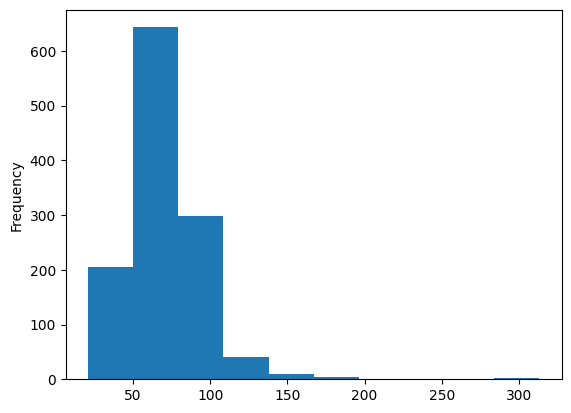

In [134]:
df['LotFrontage'].plot(kind='hist')

In [135]:
df[df['LotFrontage'].notnull()]['LotFrontage'].corr(np.sqrt(df['LotArea']))

np.float64(0.6020022167939361)

#### 2c. Missing Value Treatment
All null values resolved in one place below. Strategy: domain-verified `NA` fills for feature-absence columns, mode for single missing categoricals, median for `LotFrontage`.

In [136]:
df_clean=df.copy()
df_clean['Electrical']=df_clean['Electrical'].fillna(df_clean['Electrical'].mode()[0])

df_clean['MasVnrArea']=df_clean['MasVnrArea'].fillna(0.0)
df_clean['MasVnrType']=df_clean['MasVnrType'].fillna('None')




df_clean.loc[948,'BsmtExposure']=df_clean['BsmtExposure'].mode()[0]
#As we can see our analysis for row 232 BsmtFinType1 is 'GLQ': Good Living Quility and BsmtFinSF1 is 1124 it mean it is finished. But our BsmtUnfSF is 1603 which will be of BsmtFinType2 beacuse it's value is NaN So here will be unfinihed 

df_clean.loc[332,'BsmtFinType2']=df_clean['BsmtFinType2'].mode()[0]
df_clean['BsmtQual']=df_clean['BsmtQual'].fillna('NA')
df_clean['BsmtCond']=df_clean['BsmtCond'].fillna('NA')
df_clean['BsmtExposure']=df_clean['BsmtExposure'].fillna('NA')
df_clean['BsmtFinType1']=df_clean['BsmtFinType1'].fillna('NA')
df_clean['BsmtFinType2']=df_clean['BsmtFinType2'].fillna('NA')

df_clean['GarageType']=df_clean['GarageType'].fillna('NA')
df_clean['GarageYrBlt']=df_clean['GarageYrBlt'].fillna(0.0)
df_clean['GarageFinish']=df_clean['GarageFinish'].fillna('NA')
df_clean['GarageQual']=df_clean['GarageQual'].fillna('NA')
df_clean['GarageCond']=df_clean['GarageCond'].fillna('NA')

df_clean['LotFrontage']=df_clean['LotFrontage'].fillna(df_clean['LotFrontage'].median())

df_clean['FireplaceQu']=df_clean['FireplaceQu'].fillna('NA')

df_clean['Fence']=df_clean['Fence'].fillna('NA')

df_clean['Alley']=df_clean['Alley'].fillna('NA')

df_clean['PoolQC']=df_clean['PoolQC'].fillna('NA')

df_clean['MiscFeature']=df_clean['MiscFeature'].fillna('NA')



#### 2d. Verification — Null Check
Confirming all missing values have been resolved before proceeding.

In [137]:
df_clean.isnull().sum()[df_clean.isnull().sum() > 0]

Series([], dtype: int64)

#### 2e. Duplicates  Check
Checking for duplicate rows and verifying column data types before making corrections.

In [138]:
df_clean.duplicated().sum()

np.int64(0)

#### 2f. Data Type Corrections

In [139]:
df_clean.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
Street            object
Alley             object
LotShape          object
LandContour       object
Utilities         object
LotConfig         object
LandSlope         object
Neighborhood      object
Condition1        object
Condition2        object
BldgType          object
HouseStyle        object
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
RoofStyle         object
RoofMatl          object
Exterior1st       object
Exterior2nd       object
MasVnrType        object
MasVnrArea       float64
ExterQual         object
ExterCond         object
Foundation        object
BsmtQual          object
BsmtCond          object
BsmtExposure      object
BsmtFinType1      object
BsmtFinSF1         int64
BsmtFinType2      object
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
Heating           object


**Issue 11: MSSubClass & MoSold**  
Both stored as `int64` but represent categories (building class codes and month sold). Converted to `object`.

In [140]:
df_clean['MSSubClass'].value_counts()

MSSubClass
20     536
60     299
50     144
120     87
30      69
160     63
70      60
80      58
90      52
190     30
85      20
75      16
45      12
180     10
40       4
Name: count, dtype: int64

In [141]:
df_clean['MoSold'].value_counts()

MoSold
6     253
7     234
5     204
4     141
8     122
3     106
10     89
11     79
9      63
12     59
1      58
2      52
Name: count, dtype: int64

In [142]:
df_clean[['MSSubClass','MoSold']].dtypes

MSSubClass    int64
MoSold        int64
dtype: object

In [143]:
df_clean['YrSold'].value_counts()

YrSold
2009    338
2007    329
2006    314
2008    304
2010    175
Name: count, dtype: int64

In [144]:
df_clean['MSSubClass']=df_clean['MSSubClass'].astype('object')
df_clean['MoSold']=df_clean['MoSold'].astype('object')

In [145]:
df_clean[['MSSubClass','MoSold']].dtypes

MSSubClass    object
MoSold        object
dtype: object

**Issue 12: GarageYrBlt zeros**  
Minimum value was 0 — impossible year. Houses with no garage had 0 entered. Binned into decade ranges with `NA` category for no-garage houses.

In [146]:
(df_clean[df_clean['GarageYrBlt'] !=0.0]['GarageYrBlt'].count()/df_clean['GarageYrBlt'].count())*100

np.float64(94.45205479452055)

In [147]:
df_clean['GarageYrBlt'].corr(df_clean['YearBuilt'])

np.float64(0.2720293206017319)

In [148]:

df_clean[df_clean['GarageYrBlt'] !=0.0]['GarageYrBlt'].describe()


count    1379.000000
mean     1978.506164
std        24.689725
min      1900.000000
25%      1961.000000
50%      1980.000000
75%      2002.000000
max      2010.000000
Name: GarageYrBlt, dtype: float64

In [149]:
df_clean['GarageYrBlt']=pd.cut(df_clean['GarageYrBlt'],bins=[0,1900,1950,2000,2010,2025],labels=['NA','1900-1950','1950-2000','2000-2010','2010-2025'],include_lowest=True,right=False)

In [150]:
df_clean['GarageYrBlt'].value_counts()

GarageYrBlt
1950-2000    813
2000-2010    399
1900-1950    164
NA            81
2010-2025      3
Name: count, dtype: int64

In [151]:
df_clean['GarageYrBlt'].isna().sum()

np.int64(0)

Importing Data for manual inspection of `GarageYrBlt` and `YearBuilt` to verify no houses were built before 1870. Confirmed all houses built after 1870.

In [152]:
df_clean.to_csv("../DataSets/train_cleaned.csv",index=False)

**Issue 13: MSZoning formatting**  
`C (all)` found instead of `C` — kept as-is after confirming all commercial zone entries use this format (domain reasoning).

In [153]:
df_clean['MSZoning'].value_counts()

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

In [154]:
for col in df_clean.columns:
    if df_clean[col].dtype=='object':
        print(df_clean[col].value_counts())
        print("\n")

MSSubClass
20     536
60     299
50     144
120     87
30      69
160     63
70      60
80      58
90      52
190     30
85      20
75      16
45      12
180     10
40       4
Name: count, dtype: int64


MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64


Street
Pave    1454
Grvl       6
Name: count, dtype: int64


Alley
NA      1369
Grvl      50
Pave      41
Name: count, dtype: int64


LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64


LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64


Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64


LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64


LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64


Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     7

In [155]:
df_clean.describe()

,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,69.863699,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.117123,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,2007.815753,180921.195890
std,421.610009,22.027677,9981.264932,1.382997,1.112799,30.202904,20.645407,180.731373,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,1.328095,79442.502883
min,1.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2006.000000,34900.000000
25%,365.750000,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2007.000000,129975.000000
50%,730.500000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2008.000000,163000.000000
75%,1095.250000,79.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2009.000000,214000.000000
max,1460.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,2010.000000,755000.000000


**Issue 14: GrLivArea Outliers**  
Two rows removed: extreme area (~5600 sqft) with suspiciously low price (~160k), partial sale condition, poor overall condition, Edwards neighborhood — confirmed as non-representative data points.

In [156]:
df_clean[df_clean['GrLivArea']>3000].sort_values(by='GrLivArea',ascending=False)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,NA,IR3,Bnk,AllPub,Corner,Gtl,Edwards,Feedr,Norm,1Fam,2Story,10,5,2008,2008,Hip,ClyTile,Stucco,Stucco,Stone,796.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,5644,Unf,0,466,6110,GasA,Ex,Y,SBrkr,4692,950,0,5642,2,0,2,1,3,1,Ex,12,Typ,3,Gd,Attchd,2000-2010,Fin,2,1418,TA,TA,Y,214,292,0,0,0,480,Gd,NA,NA,0,1,2008,New,Partial,160000
523,524,60,RL,130.0,40094,Pave,NA,IR1,Bnk,AllPub,Inside,Gtl,Edwards,PosN,PosN,1Fam,2Story,10,5,2007,2008,Hip,CompShg,CemntBd,CmentBd,Stone,762.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,2260,Unf,0,878,3138,GasA,Ex,Y,SBrkr,3138,1538,0,4676,1,0,3,1,3,1,Ex,11,Typ,1,Gd,BuiltIn,2000-2010,Fin,3,884,TA,TA,Y,208,406,0,0,0,0,NA,NA,NA,0,10,2007,New,Partial,184750
1182,1183,60,RL,160.0,15623,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NoRidge,Norm,Norm,1Fam,2Story,10,5,1996,1996,Hip,CompShg,Wd Sdng,ImStucc,None,0.0,Gd,TA,PConc,Ex,TA,Av,GLQ,2096,Unf,0,300,2396,GasA,Ex,Y,SBrkr,2411,2065,0,4476,1,0,3,1,4,1,Ex,10,Typ,2,TA,Attchd,1950-2000,Fin,3,813,TA,TA,Y,171,78,0,0,0,555,Ex,MnPrv,NA,0,7,2007,WD,Abnorml,745000
691,692,60,RL,104.0,21535,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,NoRidge,Norm,Norm,1Fam,2Story,10,6,1994,1995,Gable,WdShngl,HdBoard,HdBoard,BrkFace,1170.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,1455,Unf,0,989,2444,GasA,Ex,Y,SBrkr,2444,1872,0,4316,0,1,3,1,4,1,Ex,10,Typ,2,Ex,Attchd,1950-2000,Fin,3,832,TA,TA,Y,382,50,0,0,0,0,NA,NA,NA,0,1,2007,WD,Normal,755000
1169,1170,60,RL,118.0,35760,Pave,NA,IR1,Lvl,AllPub,CulDSac,Gtl,NoRidge,Norm,Norm,1Fam,2Story,10,5,1995,1996,Hip,CompShg,HdBoard,HdBoard,BrkFace,1378.0,Gd,Gd,PConc,Ex,TA,Gd,GLQ,1387,Unf,0,543,1930,GasA,Ex,Y,SBrkr,1831,1796,0,3627,1,0,3,1,4,1,Gd,10,Typ,1,TA,Attchd,1950-2000,Fin,3,807,TA,TA,Y,361,76,0,0,0,0,NA,NA,NA,0,7,2006,WD,Normal,625000
185,186,75,RM,90.0,22950,Pave,NA,IR2,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,2.5Fin,10,9,1892,1993,Gable,WdShngl,Wd Sdng,Wd Sdng,None,0.0,Gd,Gd,BrkTil,TA,TA,Mn,Unf,0,Unf,0,1107,1107,GasA,Ex,Y,SBrkr,1518,1518,572,3608,0,0,2,1,4,1,Ex,12,Typ,2,TA,Detchd,1950-2000,Unf,3,840,Ex,TA,Y,0,260,0,0,410,0,NA,GdPrv,NA,0,6,2006,WD,Normal,475000
304,305,75,RM,87.0,18386,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,Norm,1Fam,2.5Fin,7,9,1880,2002,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,1470,1470,GasA,Ex,Y,SBrkr,1675,1818,0,3493,0,0,3,0,3,1,Gd,10,Typ,1,Ex,Attchd,2000-2010,Unf,3,870,TA,TA,Y,302,0,0,0,0,0,NA,NA,NA,0,5,2008,WD,Normal,295000
1268,1269,50,RL,69.0,14100,Pave,NA,IR1,Lvl,AllPub,Inside,Mod,Crawfor,Norm,Norm,1Fam,1.5Fin,8,9,1935,1997,Gable,CompShg,Stucco,Stucco,BrkFace,632.0,TA,Gd,CBlock,TA,TA,Mn,Rec,192,Unf,0,536,728,GasA,Ex,Y,SBrkr,1968,1479,0,3447,0,0,3,1,4,1,Gd,11,Typ,2,Gd,BuiltIn,1950-2000,Unf,3,1014,TA,TA,Y,314,12,0,0,0,0,NA,GdWo,NA,0,5,2008,WD,Normal,381000
635,636,190,RH,60.0,10896,Pave,Pave,Reg,Bnk,AllPub,Inside,Gtl,SWISU,Feedr,Norm,2fmCon,2.5Fin,6,7,1914,1995,Hip,CompShg,VinylSd,VinylSd,None,0.0,Fa,TA,CBlock,TA,Fa,No,LwQ,256,Unf,0,1184,1440,GasA,Ex,Y,FuseA,1440,1440,515,3395,0,0,2,0,8,2,Fa,14,Typ,0,NA,NA,NA,NA,0,0,NA,NA,N,0,110,0,0,0,0,NA,NA,NA,0,3,2007,WD,Abnorml,200000
769,770,60,RL,47.0,53504,Pave,NA,IR2,HLS,AllPub,CulDSac,Mod,StoneBr,Norm,Norm,1Fam,2Story,8,5,2003,2003,Hip,C

In [157]:
df_clean[df_clean['GrLivArea'] > 4000][['GrLivArea', 'SalePrice', 'OverallQual']]

,GrLivArea,SalePrice,OverallQual
523,4676,184750,10
691,4316,755000,10
1182,4476,745000,10
1298,5642,160000,10


In [158]:
df_clean.loc[[523, 1298], ['GrLivArea', 'SalePrice', 'OverallQual', 'OverallCond', 'Neighborhood', 'SaleCondition']]


,GrLivArea,SalePrice,OverallQual,OverallCond,Neighborhood,SaleCondition
523,4676,184750,10,5,Edwards,Partial
1298,5642,160000,10,5,Edwards,Partial


In [159]:
df_clean=df_clean.drop([523, 1298], axis=0)

In [160]:
df_clean.shape

(1458, 81)

### 3. **Exploratory Data Analysis**


#### 3a. Univariate Analysis — Numerical Columns

**SalePrice**  
Skew: 1.88 — highly right skewed. Applied `log1p` transformation. New skew: 0.12. Target variable is now approximately normal.

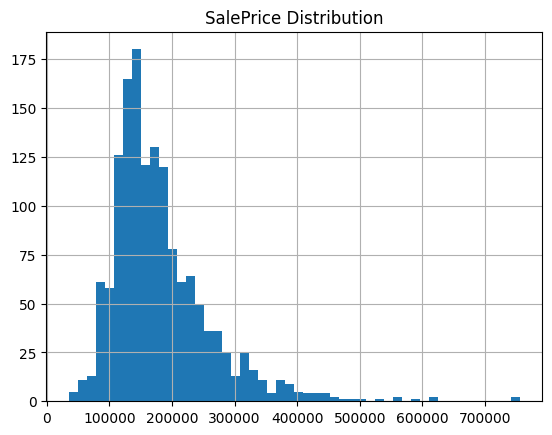

In [161]:
df_clean['SalePrice'].hist(bins=50)
plt.title('SalePrice Distribution')
plt.show()

In [162]:
df_clean['SalePrice'].skew()

np.float64(1.8812964895244009)

<Axes: >

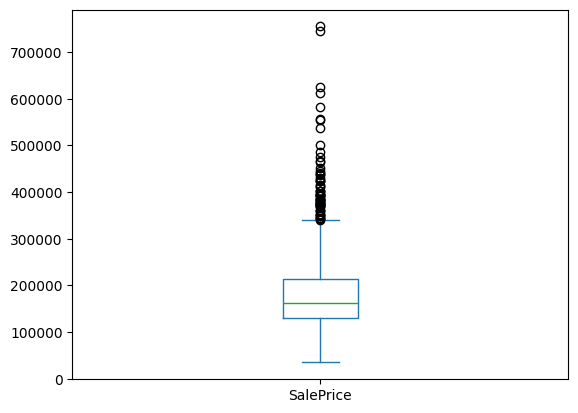

In [163]:
df_clean['SalePrice'].plot(kind='box')

In [164]:
df_clean['SalePrice'][df_clean['SalePrice'] > 330000].count()

np.int64(71)

In [165]:
df_clean['SalePrice']=np.log1p(df_clean['SalePrice'])

<Axes: ylabel='Frequency'>

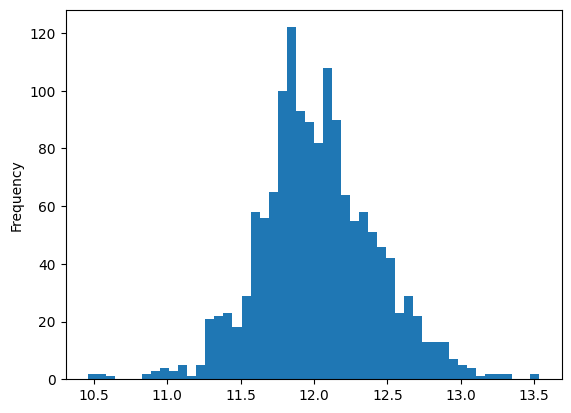

In [166]:
df_clean['SalePrice'].plot(kind='hist',bins=50)

In [167]:
df_clean['SalePrice'].skew()

np.float64(0.12157976050304882)

Rather than analyzing all 35 numerical columns individually, selected key columns based on domain intuition: `GrLivArea`, `LotFrontage`, `TotalBsmtSF`, `GarageArea`, `TotRmsAbvGrd`, `OverallCond`. Analyzed distribution and skewness for each, applying transformations where needed.

In [168]:
df_clean.select_dtypes(include=['number']).columns

Index(['Id', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'YrSold', 'SalePrice'],
      dtype='object')

**GrLivArea**  
Skew: 1.01. Found a data gap above 3500 sqft — 4 houses with extreme area but normal-to-high prices (legitimate luxury homes kept). Removed earlier 2 outliers (cleaning phase). Post-cleaning skew: 0.77 — acceptable.

<Axes: ylabel='Frequency'>

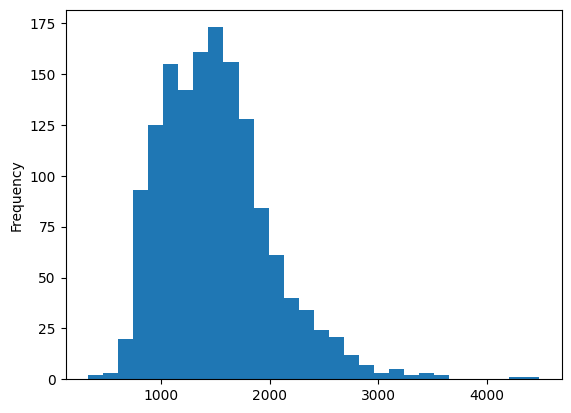

In [169]:
df_clean['GrLivArea'].plot(kind='hist',bins=30)

In [170]:
df_clean['GrLivArea'].skew()

np.float64(1.0109917025385513)

In [171]:
df_clean['GrLivArea'][df_clean['GrLivArea']<3500].skew()

np.float64(0.7749077572858002)

In [172]:
df_clean['GrLivArea'][df_clean['GrLivArea']>3500].count()

np.int64(4)

<Axes: >

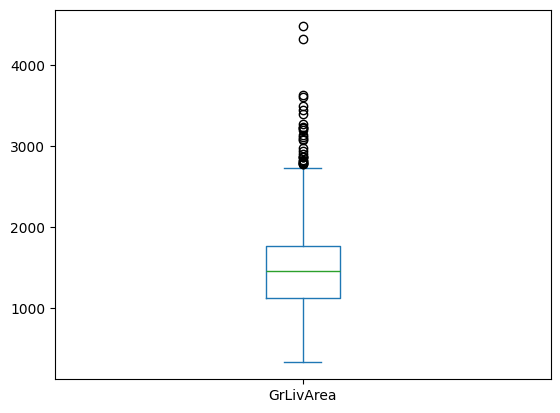

In [173]:
df_clean['GrLivArea'].plot(kind='box')

<Axes: >

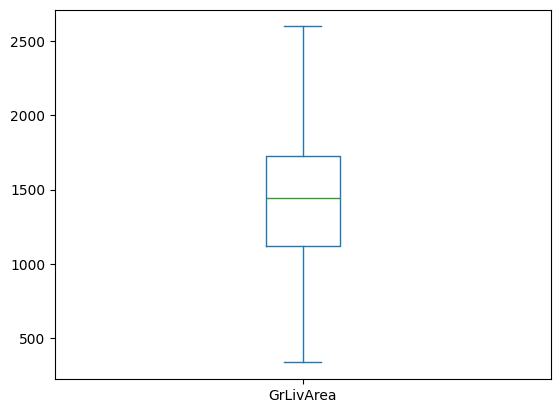

In [174]:
df_clean['GrLivArea'][df_clean['GrLivArea']<2600].plot(kind='box')

In [175]:
df_clean['GrLivArea'][df_clean['GrLivArea']>2600].count()

np.int64(51)

In [176]:
filterGrLiveArea=df_clean[df_clean['GrLivArea']>3500]
pd.concat([filterGrLiveArea['GrLivArea'],np.expm1x(filterGrLiveArea['SalePrice'])],axis=1)

,GrLivArea,SalePrice
185,3608,475000.0
691,4316,755000.0
1169,3627,625000.0
1182,4476,745000.0


In [177]:
df_clean=df_clean[df_clean['GrLivArea']<3500]

In [178]:
df_clean.shape

(1454, 81)

In [179]:
df_clean['GrLivArea'].skew()

np.float64(0.7749077572858002)

**LotFrontage**  
Skew: 1.72. Log transform overcorrected (-0.99). Applied `sqrt` instead. New skew: 0.11 — near perfect.


<Axes: ylabel='Frequency'>

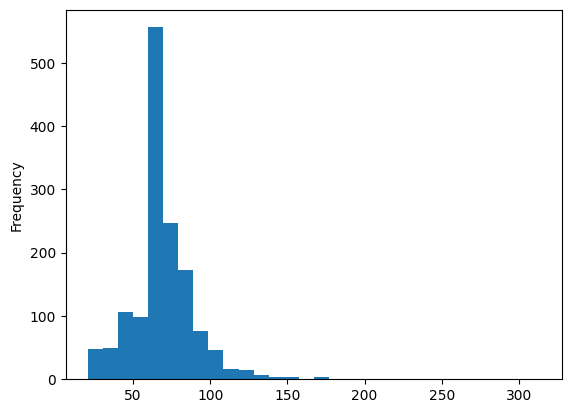

In [180]:
df_clean['LotFrontage'].plot(kind='hist',bins=30)

In [181]:
df_clean['LotFrontage'].skew()

np.float64(1.7190671323412674)

<Axes: >

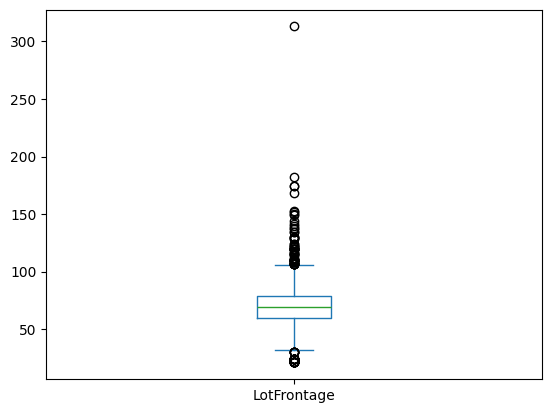

In [182]:
df_clean['LotFrontage'].plot(kind='box')

<Axes: >

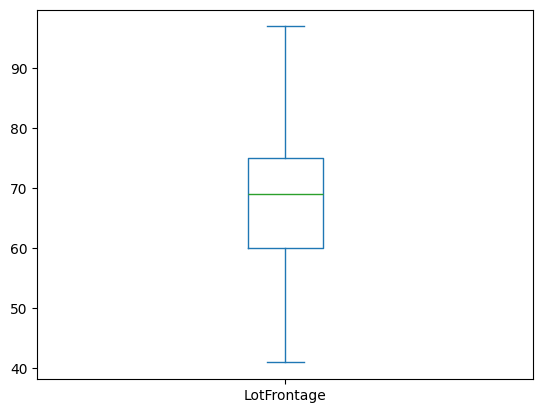

In [183]:
df_clean['LotFrontage'][(df_clean['LotFrontage']<98) & (df_clean['LotFrontage']>40)].plot(kind='box')

In [184]:
df_clean['LotFrontage'][(df_clean['LotFrontage']<98) & (df_clean['LotFrontage']>40)].skew()

np.float64(0.04636651503826309)

In [185]:
df_clean['LotFrontage'][(df_clean['LotFrontage']>98) | (df_clean['LotFrontage']<40)].count()

np.int64(184)

In [186]:
# df_clean['LotFrontage']=np.log1p(df_clean['LotFrontage'])
df_clean['LotFrontage']=np.sqrt(df_clean['LotFrontage'])


In [187]:
df_clean['LotFrontage'].skew()

np.float64(0.10863042048598058)

**OverallCond** — Treated as categorical-like rating scale, no transformation.

<Axes: ylabel='Frequency'>

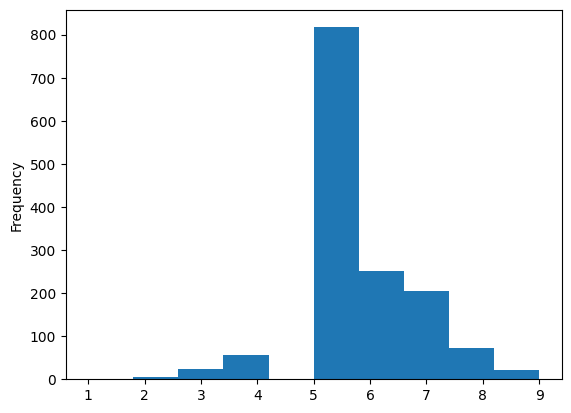

In [188]:
df_clean['OverallCond'].plot(kind='hist')

In [189]:
df_clean['OverallCond'].skew()

np.float64(0.6823521855723765)

In [190]:
df_clean['OverallCond'].value_counts()

OverallCond
5    817
6    251
7    205
8     72
4     57
3     25
9     21
2      5
1      1
Name: count, dtype: int64

**TotalBsmtSF** — Skew: 0.49 — acceptable, no transformation. 

<Axes: ylabel='Frequency'>

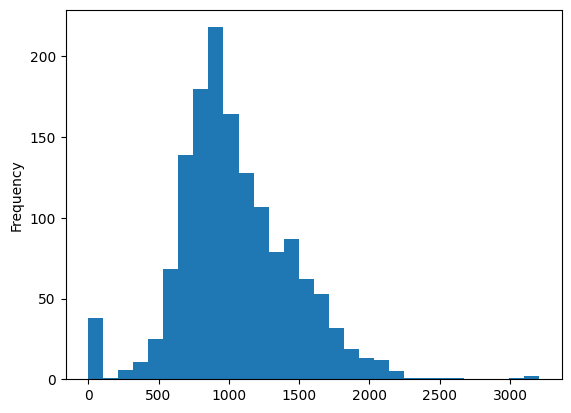

In [191]:
df_clean['TotalBsmtSF'].plot(kind='hist',bins=30)

In [192]:
df_clean['TotalBsmtSF'].skew()

np.float64(0.4863450662613742)

**GarageArea** — Skew: 0.13 — no transformation needed.

<Axes: ylabel='Frequency'>

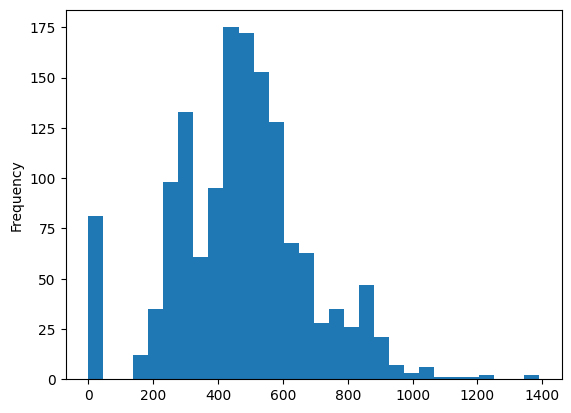

In [193]:
df_clean['GarageArea'].plot(kind='hist',bins=30)

In [194]:
df_clean['GarageArea'].skew()

np.float64(0.1341584140324636)

**TotRmsAbvGrd** — Skew: 0.65 — discrete count variable, kept as numerical. 

<Axes: ylabel='Frequency'>

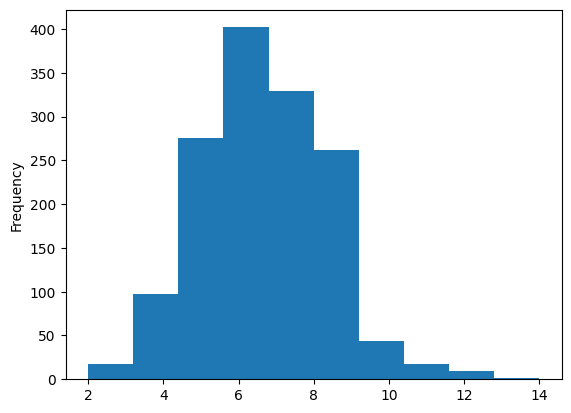

In [195]:
df_clean['TotRmsAbvGrd'].plot(kind='hist',bins=10)

In [196]:
df_clean['TotRmsAbvGrd'].skew()

np.float64(0.6490076537185153)

In [197]:
df_clean['TotRmsAbvGrd'].value_counts()

TotRmsAbvGrd
6     402
7     329
5     275
8     187
4      97
9      75
10     44
11     17
3      17
12      9
2       1
14      1
Name: count, dtype: int64

### 3b. Univariate Analysis — Categorical

Categorical column distributions were reviewed during the data cleaning phase via `value_counts()` loops. Key finding: `MSZoning` had formatting inconsistency (`C (all)`), kept after domain verification. No further univariate analysis needed for categorical columns.

#### 3c. Bivariate Analysis — Numerical vs Numerical

**GrLivArea vs SalePrice** — Scatter plot shows positive linear relationship. Correlation: 0.71 — strong predictor.


Text(0, 0.5, 'Ground Living Area')

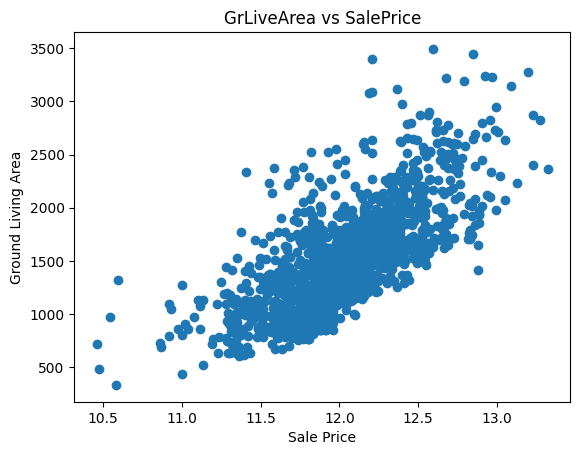

In [198]:
x_axis=df_clean['SalePrice']
y_axis=df_clean['GrLivArea']
plt.scatter(x=x_axis,y=y_axis)
plt.title('GrLiveArea vs SalePrice')
plt.xlabel('Sale Price')
plt.ylabel('Ground Living Area')


In [199]:
df_clean['SalePrice'].corr(df_clean['GrLivArea'])

np.float64(0.7146833519780494)

**Correlation Matrix** — Computed correlations of all numerical columns with `SalePrice`. Top predictors (threshold > 0.5):
- `OverallQual`: 0.82
- `GrLivArea`: 0.71  
- `GarageCars`: 0.68
- `GarageArea`: 0.65
- `TotalBsmtSF`: 0.64
- `1stFlrSF`: 0.61
- `YearBuilt`: 0.60
- `FullBath`: 0.59
- `YearRemodAdd`: 0.57
- `TotRmsAbvGrd`: 0.53

In [200]:
df_clean.select_dtypes(include='number').corr()['SalePrice'].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.817166
GrLivArea        0.714683
GarageCars       0.679118
GarageArea       0.653743
TotalBsmtSF      0.641426
1stFlrSF         0.612506
YearBuilt        0.597224
FullBath         0.588635
YearRemodAdd     0.570689
TotRmsAbvGrd     0.528521
Fireplaces       0.485657
MasVnrArea       0.420640
BsmtFinSF1       0.382659
LotFrontage      0.346004
WoodDeckSF       0.329679
OpenPorchSF      0.323263
HalfBath         0.308369
2ndFlrSF         0.297685
LotArea          0.253030
BsmtFullBath     0.239442
BsmtUnfSF        0.222658
BedroomAbvGr     0.199899
ScreenPorch      0.114276
3SsnPorch        0.056903
PoolArea         0.041177
BsmtFinSF2       0.007660
BsmtHalfBath    -0.014075
MiscVal         -0.019512
Id              -0.020708
YrSold          -0.028901
OverallCond     -0.041658
LowQualFinSF    -0.061943
KitchenAbvGr    -0.147951
EnclosedPorch   -0.148096
Name: SalePrice, dtype: float64

**Heatmap** — Top 10 columns visualized. Notable: `GarageArea` and `GarageCars` highly correlated with each other — potential multicollinearity.

<Axes: >

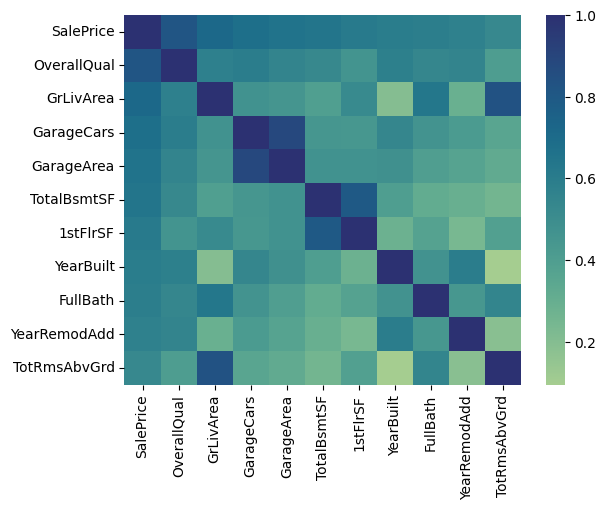

In [201]:
sns.heatmap(df_clean[['SalePrice','OverallQual','GrLivArea','GarageCars','GarageArea','TotalBsmtSF','1stFlrSF','YearBuilt','FullBath','YearRemodAdd','TotRmsAbvGrd']].corr(),cmap='crest')

**PairGrid** — Scatter matrix of top 10 columns. Discrete columns (`OverallQual`, `GarageCars`, `FullBath`) show banded patterns rather than continuous scatter.

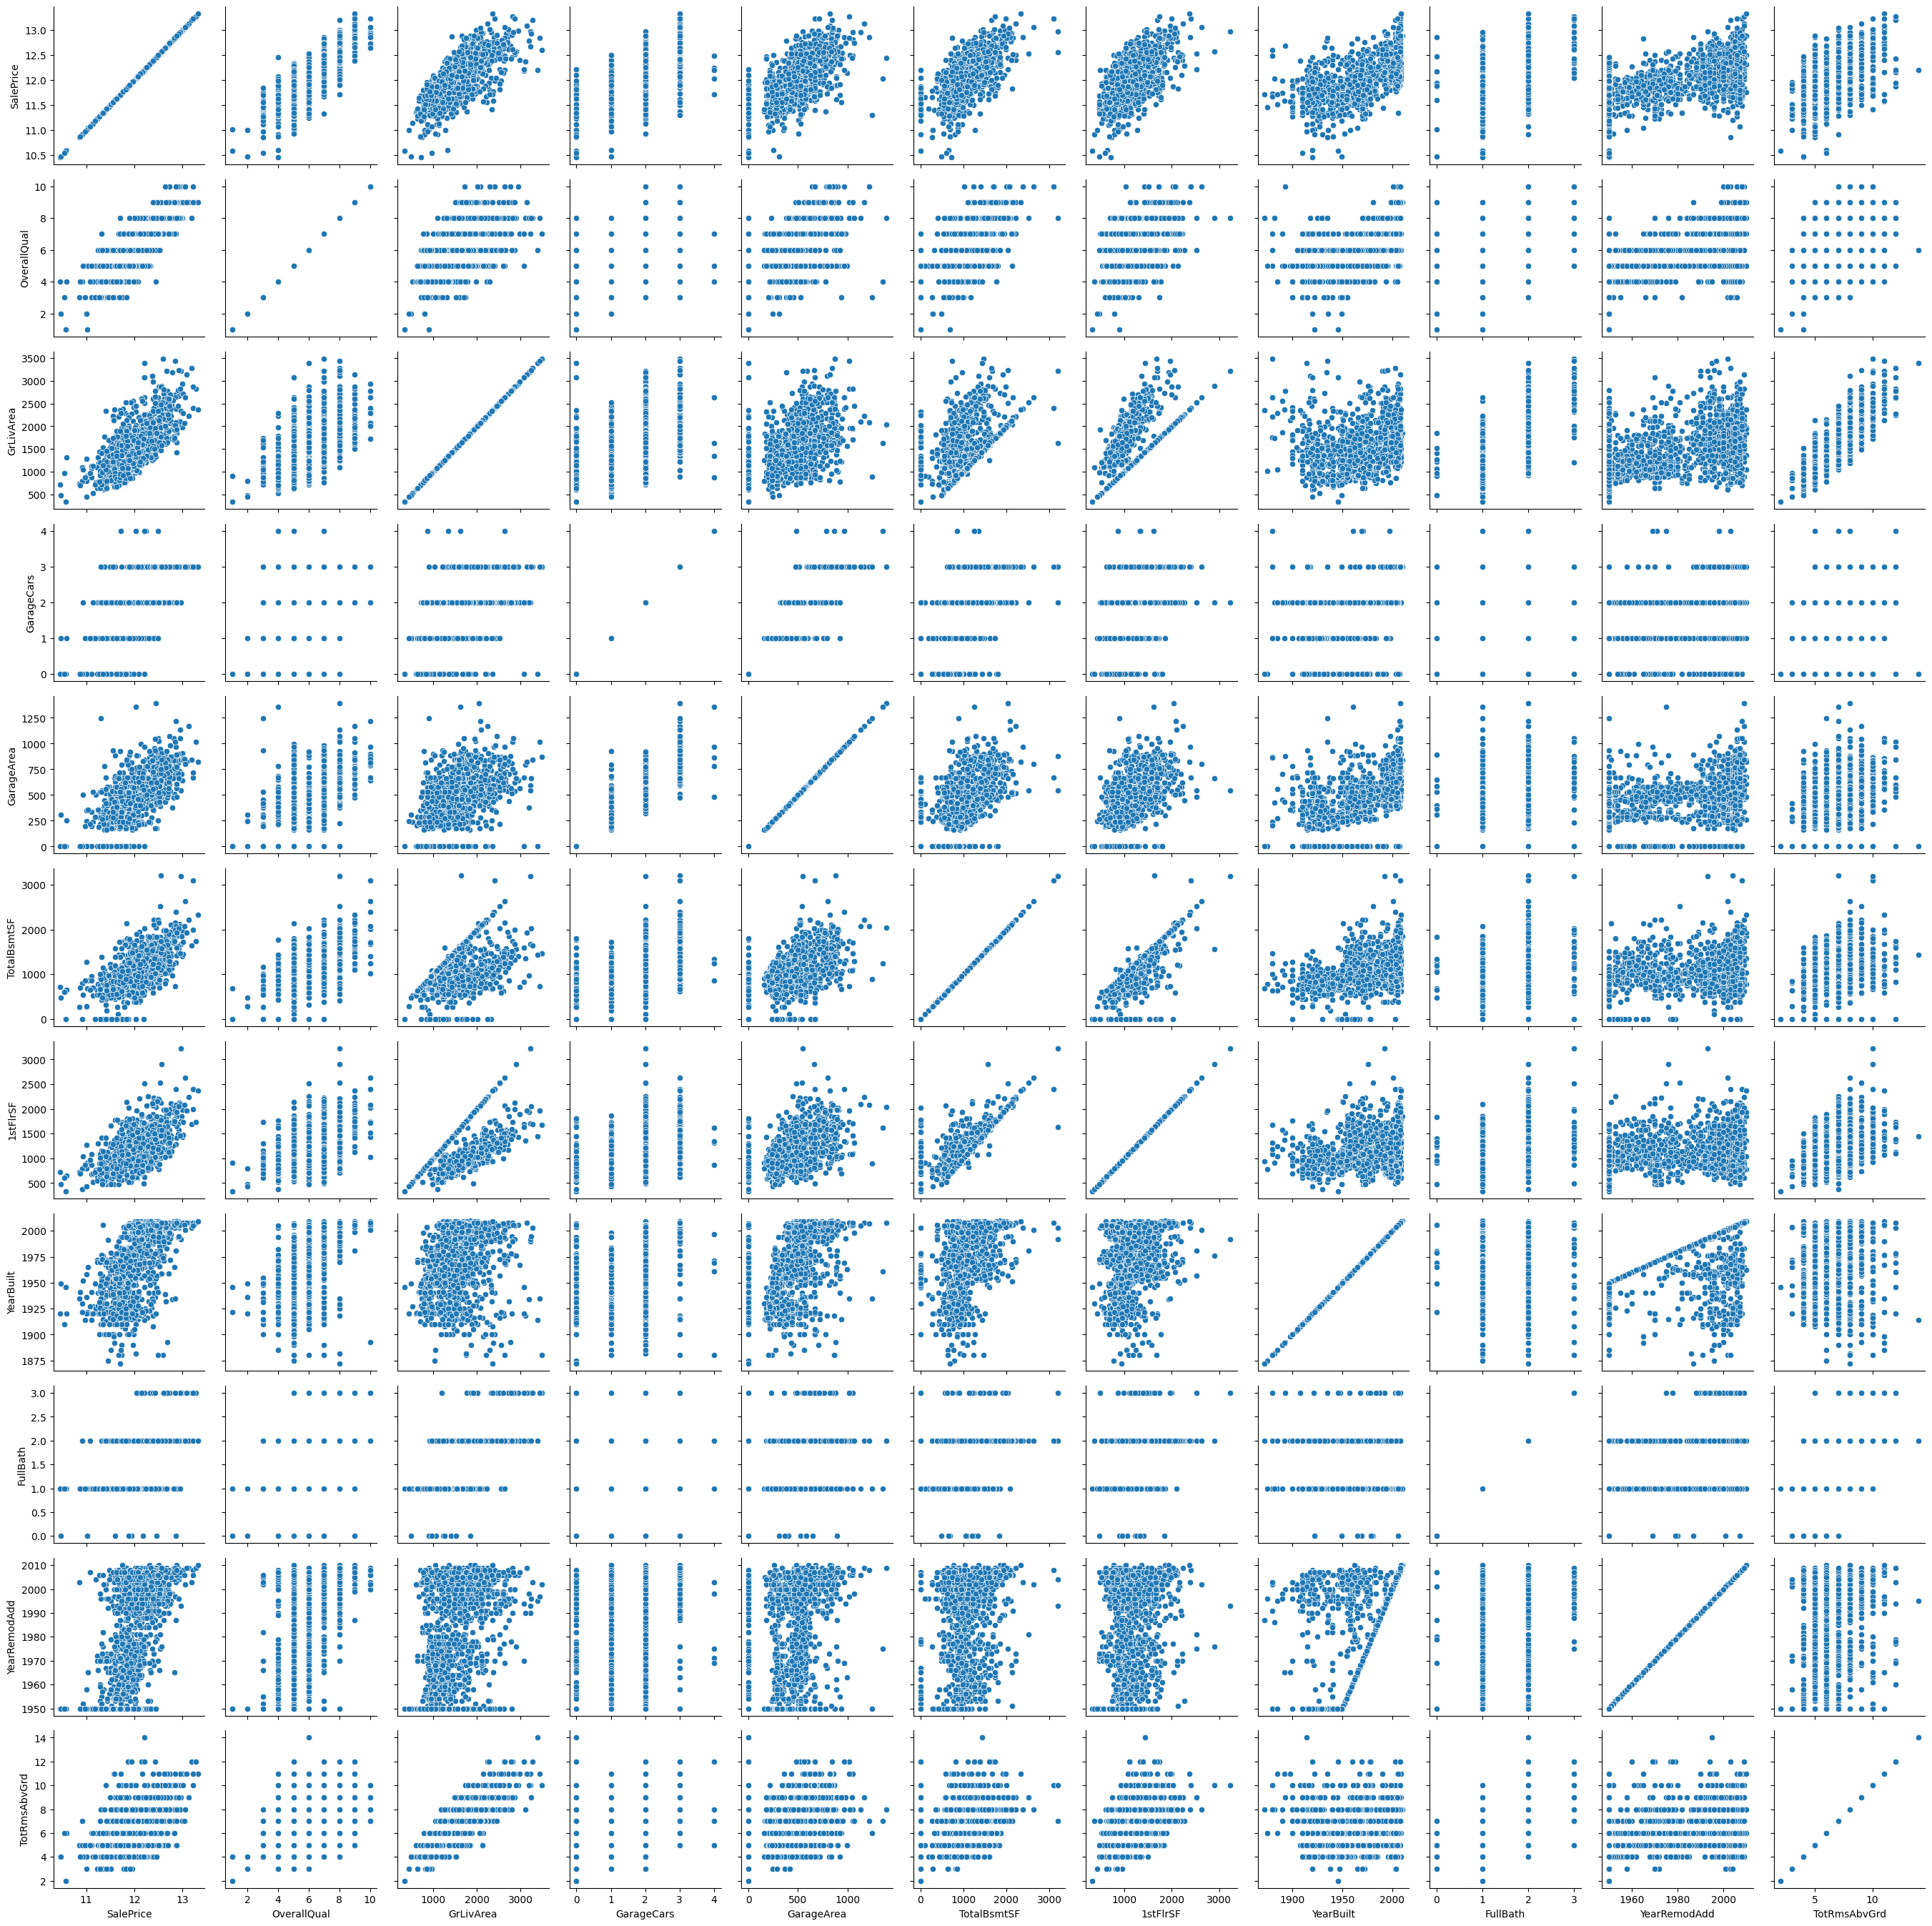

In [202]:
g=sns.PairGrid(df_clean[['SalePrice','OverallQual','GrLivArea','GarageCars','GarageArea','TotalBsmtSF','1stFlrSF','YearBuilt','FullBath','YearRemodAdd','TotRmsAbvGrd']])
g.map(sns.scatterplot)

#### 3d. Numeric-Categorical Analysis

Boxplots for discrete numerical columns against `SalePrice`:

- **OverallQual** — clear stepwise increase in price with quality

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

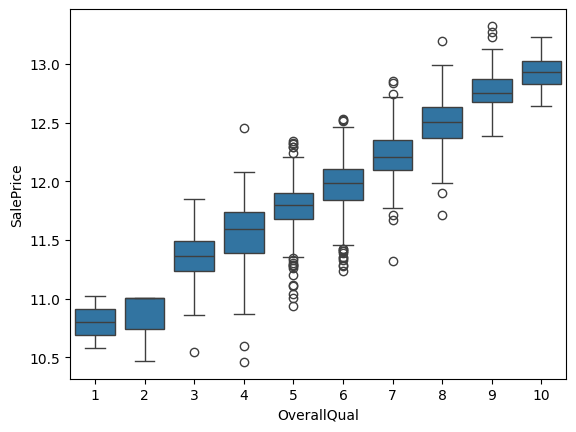

In [203]:
sns.boxplot(x='OverallQual',y='SalePrice',data=df_clean)

- **GarageCars** — positive trend, diminishing returns at 4 cars

<Axes: xlabel='GarageCars', ylabel='SalePrice'>

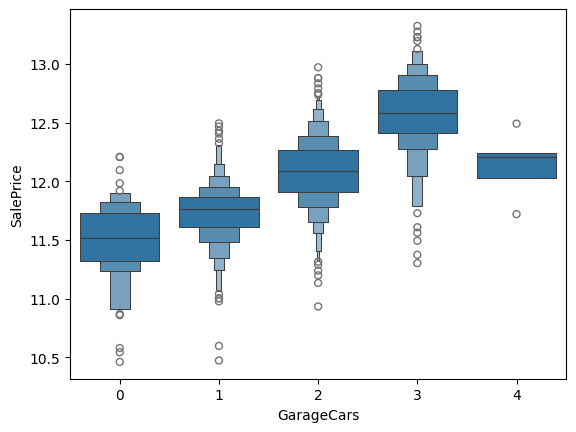

In [204]:
sns.boxenplot(x='GarageCars',y='SalePrice',data=df_clean)

- **TotRmsAbvGrd** — positive trend, plateaus after 11 rooms

<Axes: xlabel='TotRmsAbvGrd', ylabel='SalePrice'>

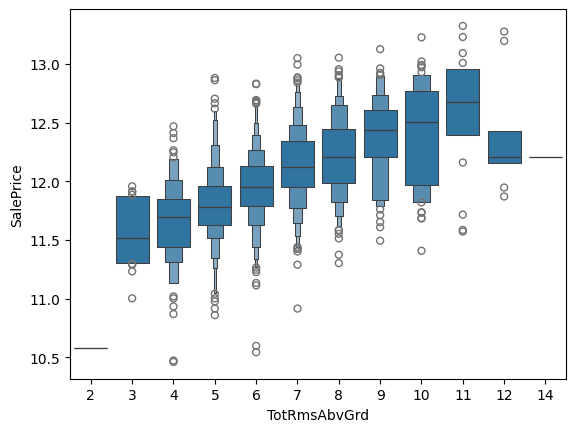

In [205]:
sns.boxenplot(x='TotRmsAbvGrd',y='SalePrice',data=df_clean)

#### 3e. Categorical Column Selection by Price Spread

Computed mean `SalePrice` per category for all object columns. Kept columns where spread > 0.90 between highest and lowest category mean. Plotted boxplots for all selected columns.

In [206]:
x=df_clean.select_dtypes(include='object').columns
prices_spreadD=dict()
for i in x:
    prices_mean=df_clean.groupby(i)['SalePrice'].mean().sort_values(ascending=False)
    prices_spread=prices_mean.max()-prices_mean.min()
    if prices_spread>0.90:
        prices_spreadD[i]=prices_spread
sorted_spreads = dict(sorted(prices_spreadD.items(), key=lambda item: item[1], reverse=True))
for col, spread in sorted_spreads.items():
    print(f"{col}: {spread}") 
         

ExterQual: 1.4727169698606488
Condition2: 1.425660891200975
Exterior1st: 1.3178019850168425
Neighborhood: 1.1725140588204006
BsmtCond: 1.1547300478216407
MSZoning: 1.1283452553516202
KitchenQual: 1.1177799056323607
Exterior2nd: 1.1112243636544736
BsmtQual: 1.0994237143813752
MiscFeature: 1.072610910916321
Electrical: 0.9450603872004191
SaleCondition: 0.924707971752099


**Key finding:** `ExterQual`, `KitchenQual`, `BsmtQual` show strong ordinal price relationships (Ex > Gd > TA > Fa). `Neighborhood` shows largest geographic price variation.

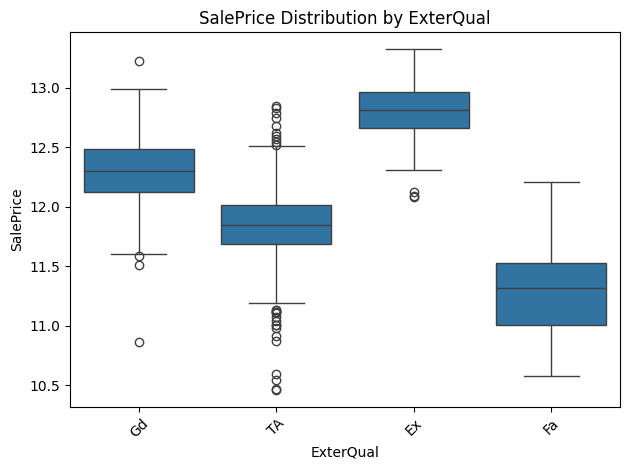

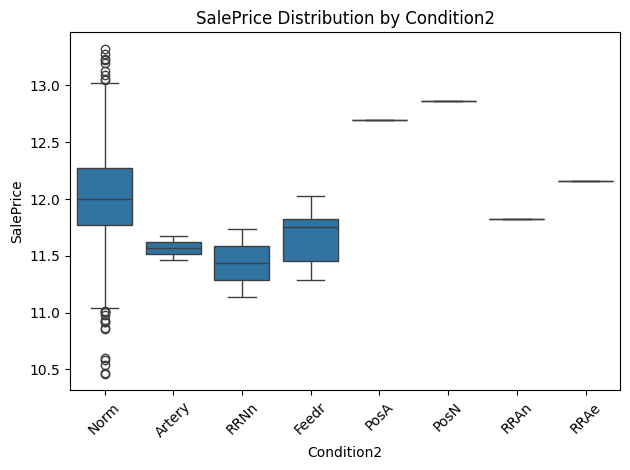

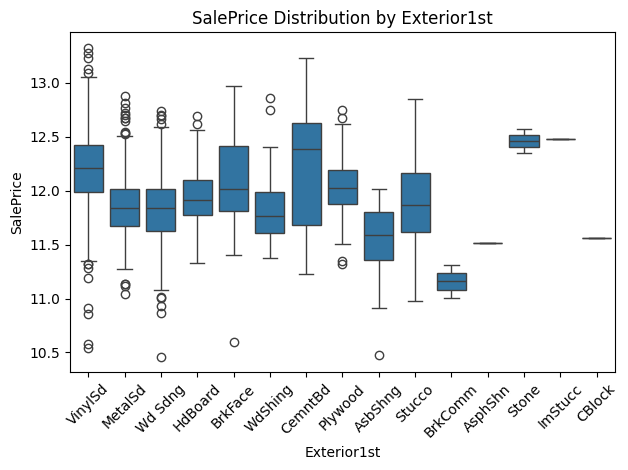

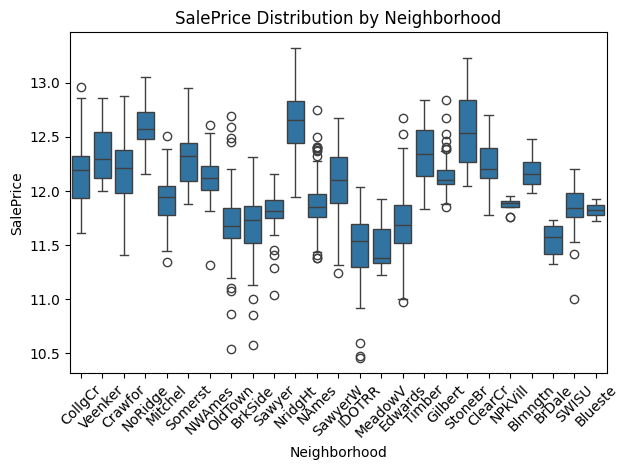

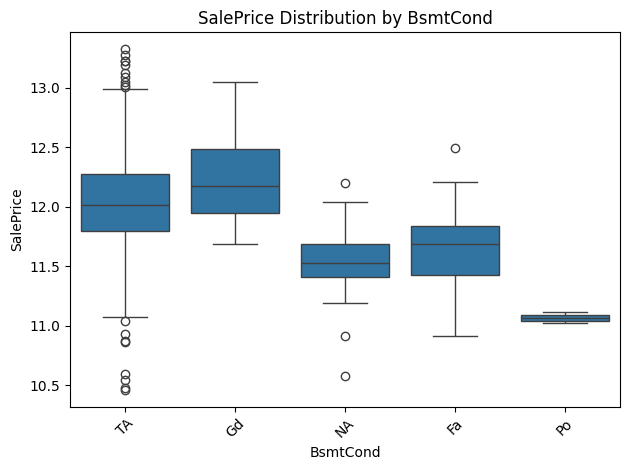

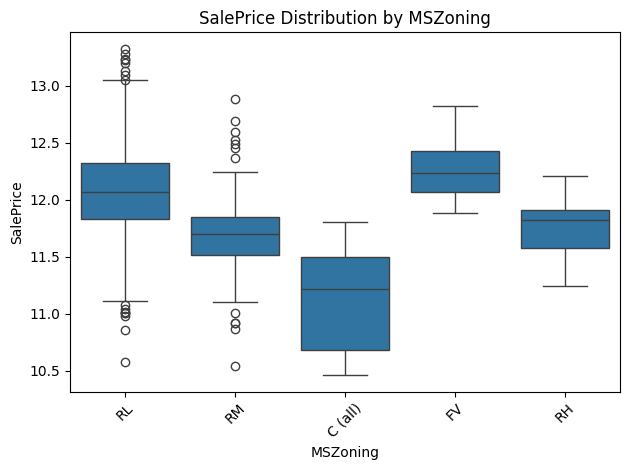

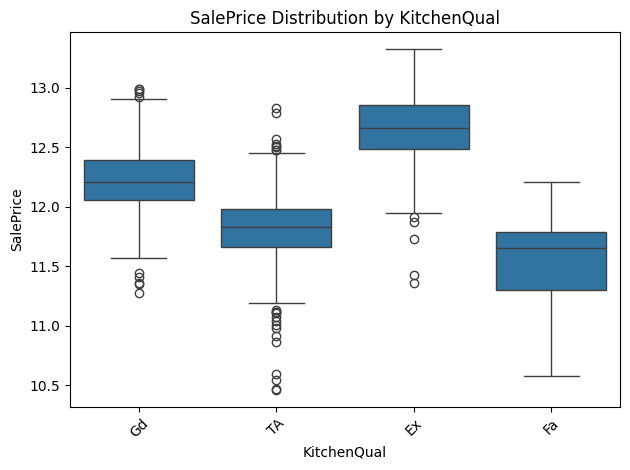

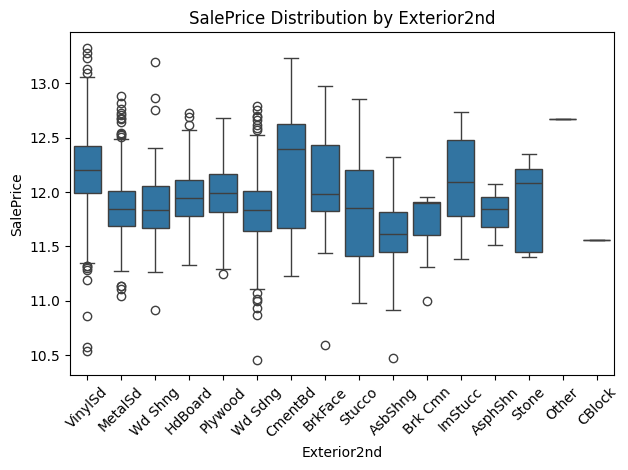

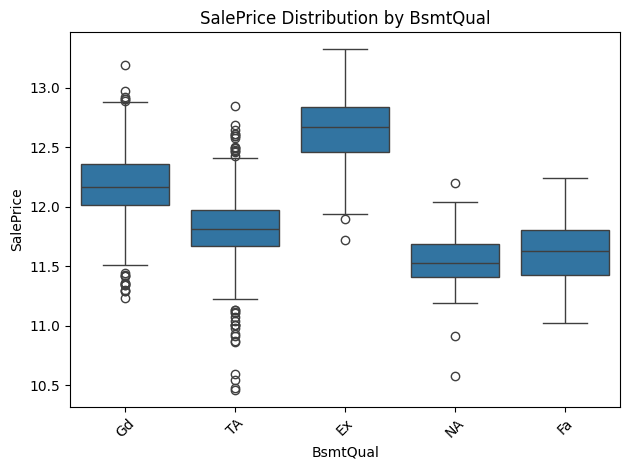

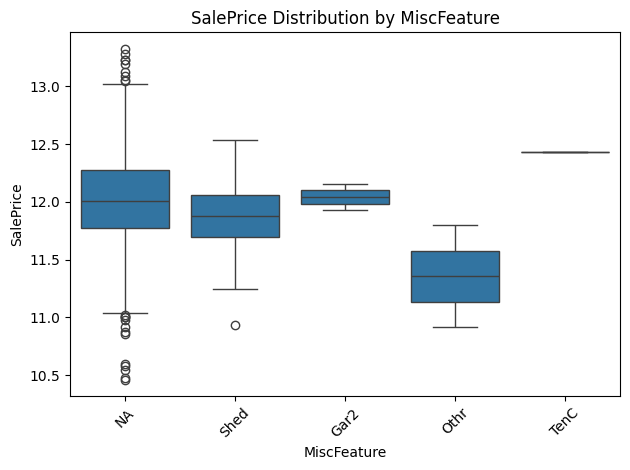

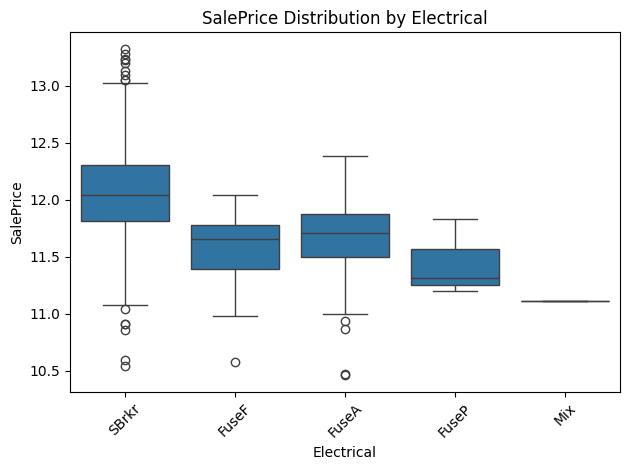

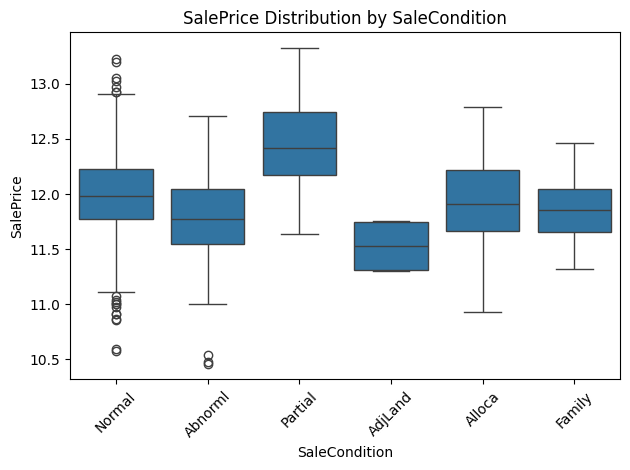

In [207]:
for col in sorted_spreads.keys():
    plt.Figure(figsize=(10,6))
    sns.boxplot(x=col,y='SalePrice',data=df_clean)
    plt.xticks(rotation=45)
    plt.title(f'SalePrice Distribution by {col}')
    plt.tight_layout()
    plt.show()

#### 3f. Categorical vs Categorical Analysis

Crosstab of `ExterQual` vs `Neighborhood` — examining whether exterior quality varies by neighborhood.

**Finding:** Premium neighborhoods (NridgHt, NoRidge) concentrate `Ex` and `Gd` ratings. Older neighborhoods (OldTown, Edwards) skew toward `TA`. Suggests `Neighborhood` and `ExterQual` may carry overlapping information — potential multicollinearity to address in feature engineering.

In [208]:
pd.crosstab(df_clean['ExterQual'],df_clean['Neighborhood'])

Neighborhood,Blmngtn,Blueste,BrDale,BrkSide,ClearCr,CollgCr,Crawfor,Edwards,Gilbert,IDOTRR,MeadowV,Mitchel,NAmes,NPkVill,NWAmes,NoRidge,NridgHt,OldTown,SWISU,Sawyer,SawyerW,Somerst,StoneBr,Timber,Veenker
ExterQual,,,,,,,,,,,,,,,,,,,,,,,,,
Ex,0,0,0,0,0,0,2,1,2,0,0,0,2,0,1,1,28,1,0,0,0,5,4,2,0
Fa,0,0,0,3,0,0,0,1,0,5,0,0,0,0,0,0,0,3,1,0,1,0,0,0,0
Gd,17,0,0,4,7,109,13,8,41,1,0,5,14,0,11,37,48,7,2,2,33,74,21,23,8
TA,0,2,16,51,21,41,36,88,36,31,17,44,209,9,61,0,1,101,22,72,25,7,0,13,3


#### 3g. Multivariate Analysis

Heatmap and PairGrid across top 10 correlated columns confirmed that `OverallQual` has the strongest combined effect on `SalePrice`. Feature interactions visible — `GarageArea` and `GarageCars` overlap significantly, as do `TotalBsmtSF` and `1stFlrSF`.

In [209]:
df_clean.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,8.062258,8450,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NA,Attchd,2000-2010,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NA,NA,NA,0,2,2008,WD,Normal,12.247699
1,2,20,RL,8.944272,9600,Pave,NA,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1950-2000,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NA,NA,NA,0,5,2007,WD,Normal,12.109016
2,3,60,RL,8.246211,11250,Pave,NA,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2000-2010,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NA,NA,NA,0,9,2008,WD,Normal,12.317171
3,4,70,RL,7.745967,9550,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1950-2000,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NA,NA,NA,0,2,2006,WD,Abnorml,11.849405
4,5,60,RL,9.165151,14260,Pave,NA,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000-2010,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NA,NA,NA,0,12,2008,WD,Normal,12.429220


### 4. EDA Conclusion



**Strongest predictors:** `OverallQual` (0.82), `GrLivArea` (0.71), `GarageCars` (0.68), `TotalBsmtSF` (0.64). For categorical columns: `ExterQual`, `Neighborhood`, `KitchenQual` show largest price variation across categories.

**Transformations applied:** `log1p` on `SalePrice` (skew 1.88 → 0.12), `sqrt` on `LotFrontage` (skew 1.72 → 0.11), `log1p` on `GrLivArea` skew reduced to 0.77.

**Focus for modeling:** Top numerical predictors + high-spread categorical columns. Watch for multicollinearity between `GarageArea`/`GarageCars` and `TotalBsmtSF`/`1stFlrSF`.

### 5. Next Steps

EDA complete. Proceeding to feature engineering — encoding categorical variables, handling multicollinearity, and creating new features — followed by model development starting with Linear Regression.

In [210]:
df_clean.to_csv("../DataSets/ames_clean.csv")

### Export Cleaned Dataset

The cleaned DataFrame is exported as a CSV file for use in subsequent notebooks, such as preprocessing and modeling.

> **Important:** During the cleaning process, missing values representing "feature does not exist" were replaced with the string `"NA"`. When reading the CSV with Pandas, `"NA"` can otherwise be automatically interpreted as a `NaN` value because it is one of Pandas' default missing-value markers.

Therefore, when loading this dataset in another notebook, use:

```python
df = pd.read_csv(
    "../DataSets/ames_clean.csv",
    keep_default_na=False
)
```

This ensures that `"NA"` remains a **categorical value** rather than being converted back into `NaN`.

The exported dataset contains **1,454 rows and 81 columns**, with missing values already handled during the cleaning stage.
